# Building User Features and Segmentation
**Dataset:** Transactional data (March–May 2024)  
**Objective:**  
1. Engineer user-level behavioral features from raw transaction data  
2. Infer latent demographic and personality attributes from behavioral signals  
3. Segment users into distinct, actionable groups  


## Section 1 — Business Understanding

Financial services companies sit on one of the most underutilized assets in data science: raw transaction logs. Every swipe, tap, or balance transfer contains latent signals about who a person is, their lifestyle, priorities, financial discipline, and even personality tendencies.

This project builds a **behavioral intelligence pipeline** on top of transactional data from an Indonesian digital payment platform. The goal is to move from raw rows to user-level understanding, enabling:

- **Personalized marketing**: Serve offers that match real spending behavior, not generic demographics
- **Loyalty optimization**: Identify users most likely to respond to loyalty programs vs. those needing activation
- **Product recommendation**: Match financial products (insurance, credit, investment) to inferred life stage
- **Risk profiling**: Detect financially stressed users before they churn or default

The approach has three layers:
1. **Feature Engineering** — convert transaction-level data into user-level behavioral signals
2. **Attribute Inference** — estimate demographic and personality traits from behavioral patterns
3. **Segmentation** — group users into actionable archetypes with distinct business implications

> All demographic inferences are **probabilistic behavioral estimates**, not factual labels. They reflect statistical tendencies derived from population-level patterns, not ground truth about any individual.


## Section 2 — Dataset Overview

**Key dataset characteristics:**
- **278,932 transactions** across **24,321 unique users**, spanning **March 1 – May 31, 2024** (92 days)
- Zero null values, no imputation required
- Transaction amounts in IDR, ranging from Rp 1,000 to Rp 587,100 (mean ~Rp 50,098)
- 21 unique MCC (Merchant Category Code) codes, fully mappable to lifestyle categories
- Geographic coordinates covering 3 Indonesian city clusters: Jakarta, Surabaya, Yogyakarta
- Device data via `user_agent`: Android versions + iPhone/iPad, socioeconomic proxy
- `transaction_notes`: binary yes/no field (not free text despite the field name)
- **Important data limitation**: `transaction_date` contains date only,  no time component, contrary to the dataset description. All hour-based features (late-night ratio, work-hour ratio) are excluded and compensated with richer date-level signals (payday window, weekday diversity, monthly consistency).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

df = pd.read_csv(r'C:\Users\A\Downloads\transactions.csv')
print(f'Rows: {len(df):,}')
print(f'Unique users: {df["user_id"].nunique():,}')
print(f'Date range: {df["transaction_date"].min()} to {df["transaction_date"].max()}')
print(f'Nulls: {df.isnull().sum().sum()}')
df.head()

Rows: 278,932
Unique users: 24,321
Date range: 2024-03-01 to 2024-05-31
Nulls: 0


,transaction_id,user_id,transaction_amount,transaction_date,merchant_id,merchant_name,merchant_category_id,geo_location,payment_method,user_agent,loyalty_program,discount_applied,promo_amount,transaction_notes,merchant_rating,transaction_status,is_refunded
0,4a71b7d1-34fa-45cf-b40a-a730d16ce617,U10578,23500.0,2024-05-09,M04936,Cox Inc,5732,"-7.974781, 112.633863",balance,Android 9,no,no,0.0,no,5,completed,no
1,b29665c0-8373-4ec1-a121-a041c77ffb51,U08353,150500.0,2024-05-30,M06359,"King, Rice and Ramirez",5812,"-6.188155, 106.817086",balance,iPhone; CPU iPhone OS 3_1_3 like Mac OS X,no,no,0.0,yes,2,completed,no
2,3e32187b-b374-4f1b-a64e-b1ebcc856563,U04564,65800.0,2024-03-08,M01710,"Lyons, Porter and Williams",5812,"-7.962043, 112.637274",credit_card,Android 2.0.1,no,no,0.0,no,3,completed,no
3,df8ad42e-aaf6-46d2-8d8f-1e291a4554bd,U22797,45600.0,2024-05-14,M02852,Smith Ltd,5411,"-6.592793, 106.806543",balance,iPad; CPU iPad OS 9_3_5 like Mac OS X,no,no,0.0,no,3,completed,no
4,334468df-4d71-4e4a-935c-32c17c306611,U18053,8500.0,2024-04-09,M00722,Bush Group,5411,"-6.269386, 106.979043",balance,Android 2.0.1,yes,no,0.0,no,4,completed,no


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278932 entries, 0 to 278931
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   transaction_id        278932 non-null  object 
 1   user_id               278932 non-null  object 
 2   transaction_amount    278932 non-null  float64
 3   transaction_date      278932 non-null  object 
 4   merchant_id           278932 non-null  object 
 5   merchant_name         278932 non-null  object 
 6   merchant_category_id  278932 non-null  int64  
 7   geo_location          278932 non-null  object 
 8   payment_method        278932 non-null  object 
 9   user_agent            278932 non-null  object 
 10  loyalty_program       278932 non-null  object 
 11  discount_applied      278932 non-null  object 
 12  promo_amount          278932 non-null  float64
 13  transaction_notes     278932 non-null  object 
 14  merchant_rating       278932 non-null  int64  
 15  

In [3]:
df.describe()

,transaction_amount,merchant_category_id,promo_amount,merchant_rating
count,278932.000000,278932.000000,278932.000000,278932.00000
mean,50098.301378,5806.529964,4311.858087,3.80046
std,50021.138491,509.152141,16527.140346,1.16671
min,1000.000000,4722.000000,0.000000,1.00000
25%,14400.000000,5541.000000,0.000000,3.00000
50%,34800.000000,5812.000000,0.000000,4.00000
75%,69400.000000,5912.000000,0.000000,5.00000
max,587100.000000,8220.000000,422600.000000,5.00000


**Column notes:**
- `transaction_amount`: in IDR (Indonesian Rupiah), range ~1,000 to ~587,000
- `geo_location`: lat/lon pairs, coordinates indicate Indonesian cities (Jakarta, Surabaya, Yogyakarta)
- `merchant_category_id`: Visa MCC codes, maps to lifestyle categories
- `user_agent`: device type, Android versions + iPhone/iPad
- `transaction_notes`: yes/no, whether the user attached a note (purchase intent signal)
- `payment_method`: balance or credit_card

## Section 3 — Data Cleaning & Preprocessing

In [4]:
# Parse transaction dates and extract calendar components
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
df['weekday'] = df['transaction_date'].dt.weekday          # 0=Mon, 6=Sun
df['month'] = df['transaction_date'].dt.month
df['day_of_month'] = df['transaction_date'].dt.day
df['is_weekend'] = (df['weekday'] >= 5).astype(int)

# Note: transaction_date contains date only — no time component exists in this dataset.
# Hour-based features (late-night ratio, work-hour ratio) cannot be derived.
# We compensate with date-level signals: payday window, weekday diversity, monthly consistency.

# Indonesian salary cycle: most workers are paid between the 25th and 3rd of each month
df['is_payday_window'] = ((df['day_of_month'] >= 25) | (df['day_of_month'] <= 3)).astype(int)

# Split geo_location string into separate latitude and longitude columns
df[['lat', 'lon']] = df['geo_location'].str.split(', ', expand=True).astype(float)

# Convert yes/no string columns to binary integers
bool_cols = ['loyalty_program', 'discount_applied', 'is_refunded', 'transaction_notes']
for col in bool_cols:
    df[col] = (df[col] == 'yes').astype(int)

# Flag failed transactions and credit card payments for downstream use
df['is_failed'] = (df['transaction_status'] == 'failed').astype(int)
df['is_credit_card'] = (df['payment_method'] == 'credit_card').astype(int)

# Detect iOS devices — used as a socioeconomic proxy in 5F
df['is_ios'] = df['user_agent'].str.contains('iPhone|iPad', case=False, na=False).astype(int)

def get_android_version(ua):
    if 'Android' in str(ua):
        try:
            ver = ua.split('Android ')[1].split()[0].rstrip(';')
            return float(ver.split('.')[0])
        except:
            return np.nan
    return np.nan

df['android_version'] = df['user_agent'].apply(get_android_version)

print('Preprocessing done.')
df[['transaction_date','weekday','is_weekend','is_payday_window','lat','lon','is_ios','android_version']].head()


Preprocessing done.


,transaction_date,weekday,is_weekend,is_payday_window,lat,lon,is_ios,android_version
0,2024-05-09,3,0,0,-7.974781,112.633863,0,9.0
1,2024-05-30,3,0,1,-6.188155,106.817086,1,NaN
2,2024-03-08,4,0,0,-7.962043,112.637274,0,2.0
3,2024-05-14,1,0,0,-6.592793,106.806543,1,NaN
4,2024-04-09,1,0,0,-6.269386,106.979043,0,2.0


In [5]:
# Map Visa MCC codes to human-readable category labels.
# This is essential — raw MCC integers are uninterpretable for behavioral inference.
# Two grocery codes (5411, 5412) are merged into one label.
# Two fashion codes (5651, 5661) are merged. Two education codes (8211, 8220) are merged.
mcc_map = {
    4722: 'travel',
    5251: 'hardware_store',
    5311: 'department_store',
    5411: 'grocery',
    5412: 'grocery',
    5541: 'fuel',
    5651: 'fashion',
    5661: 'fashion',
    5712: 'furniture',
    5732: 'electronics',
    5812: 'restaurant',
    5814: 'fast_food',
    5912: 'pharmacy',
    5941: 'sports',
    5942: 'books',
    5964: 'catalog_retail',
    5999: 'misc_retail',
    7230: 'beauty',
    7994: 'gaming',
    8211: 'education',
    8220: 'education'
}

df['mcc_label'] = df['merchant_category_id'].map(mcc_map)
print('MCC label distribution:')
print(df['mcc_label'].value_counts())


MCC label distribution:
restaurant          67255
grocery             40370
fast_food           38435
pharmacy            26525
electronics         13663
misc_retail         13497
fuel                13022
fashion             11261
hardware_store       8043
books                7927
department_store     5826
furniture            5596
education            5474
beauty               5217
sports               5138
catalog_retail       4766
travel               4375
gaming               2542
Name: mcc_label, dtype: int64


## Section 4 — Exploratory Data Analysis

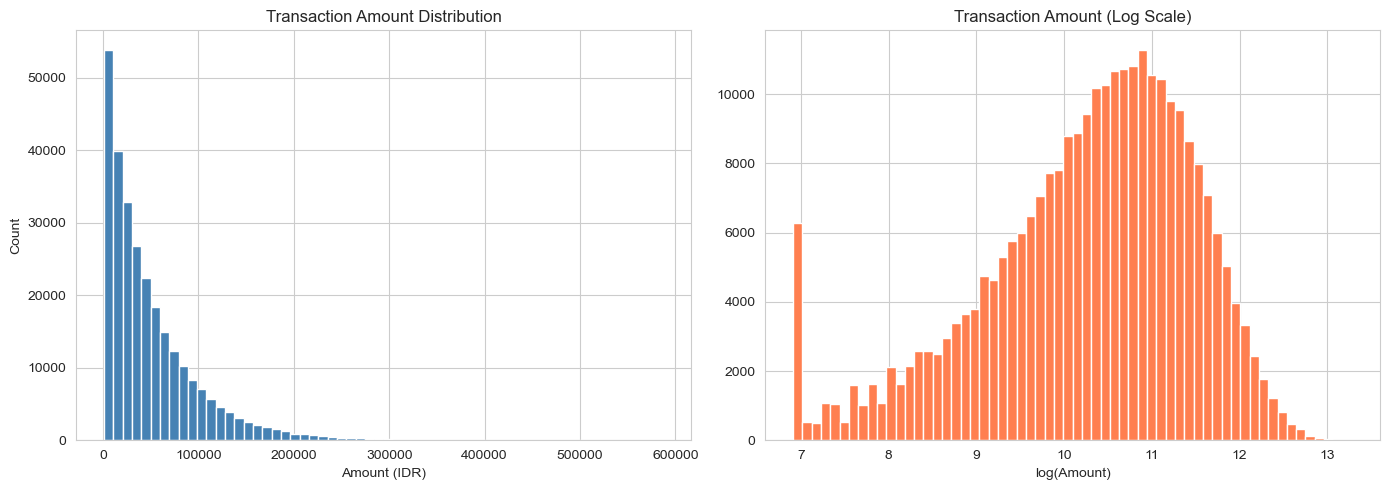

Most transactions are small-to-medium, with a long right tail indicating high-spend outliers.


In [6]:
# Transaction amount distribution, raw and log-scaled.
# The log scale reveals the full shape without high-value outliers dominating.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['transaction_amount'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount (IDR)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df['transaction_amount']), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Transaction Amount (Log Scale)')
axes[1].set_xlabel('log(Amount)')

plt.tight_layout()
plt.show()
print('Most transactions are small-to-medium, with a long right tail indicating high-spend outliers.')


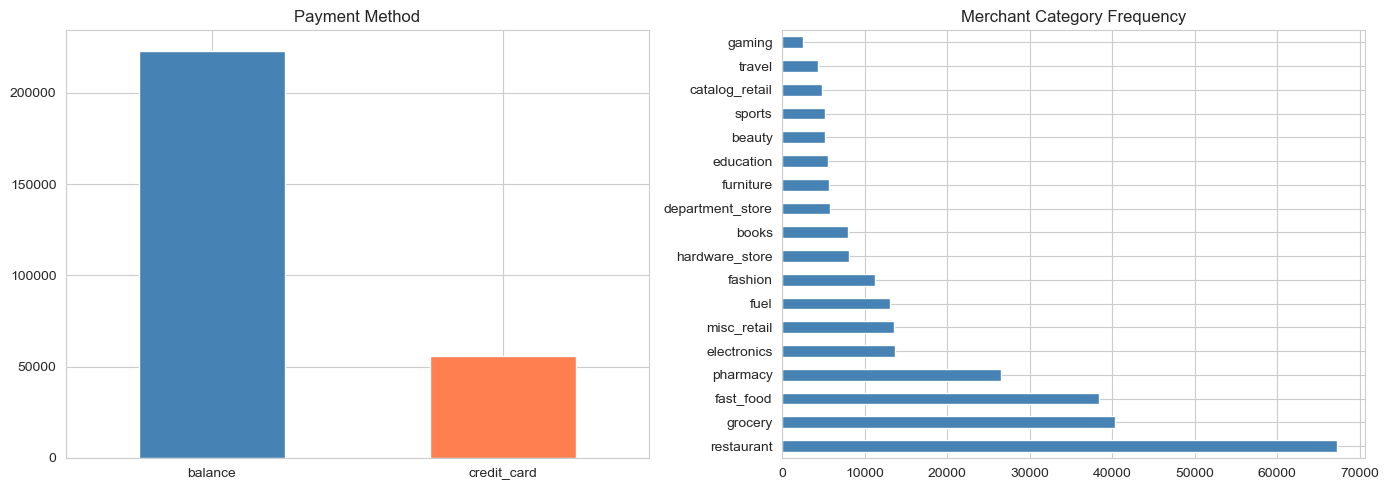

In [7]:
# Payment method split and merchant category frequency.
# Balance dominates over credit card, relevant for income inference in 6A.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['payment_method'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','coral'])
axes[0].set_title('Payment Method')
axes[0].tick_params(axis='x', rotation=0)

df['mcc_label'].value_counts().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Merchant Category Frequency')

plt.tight_layout()
plt.show()


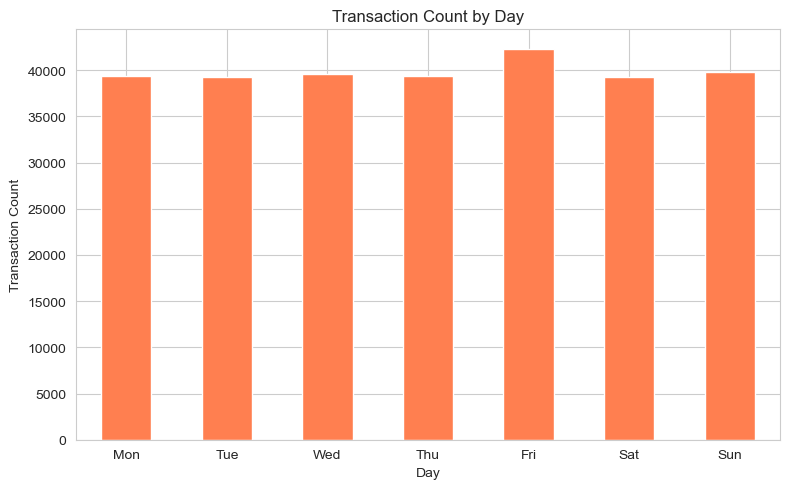

In [8]:
# Transaction volume by day of week.
# Relatively flat distribution suggests no strong day-of-week behavioral pattern.
plt.figure(figsize=(8, 5))
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
df.groupby('weekday')['transaction_amount'].count().plot(kind='bar', color='coral')
plt.xticks(range(7), day_labels, rotation=0)
plt.title('Transaction Count by Day')
plt.xlabel('Day')
plt.ylabel('Transaction Count')
plt.tight_layout()
plt.show()


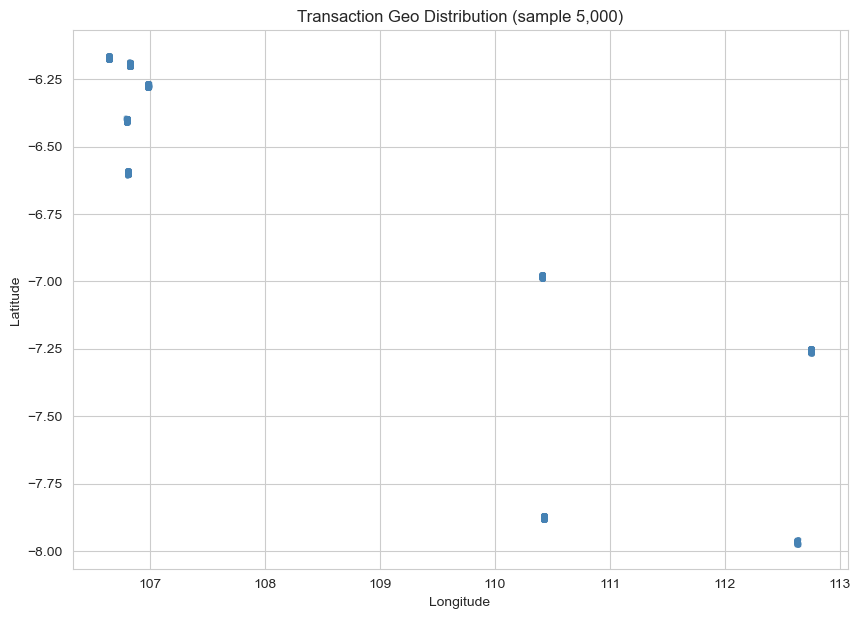

Clusters visible around Jakarta (~106.8E), Surabaya (~112.7E), and Yogyakarta (~110.4E)


In [9]:
# Geographic distribution of transactions (5,000-point sample).
# Three distinct clusters confirm this dataset covers Jakarta, Surabaya, and Yogyakarta.
plt.figure(figsize=(10, 7))
plt.scatter(df['lon'].sample(5000, random_state=42),
            df['lat'].sample(5000, random_state=42),
            alpha=0.3, s=5, color='steelblue')
plt.title('Transaction Geo Distribution (sample 5,000)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()
print('Clusters visible around Jakarta (~106.8E), Surabaya (~112.7E), and Yogyakarta (~110.4E)')


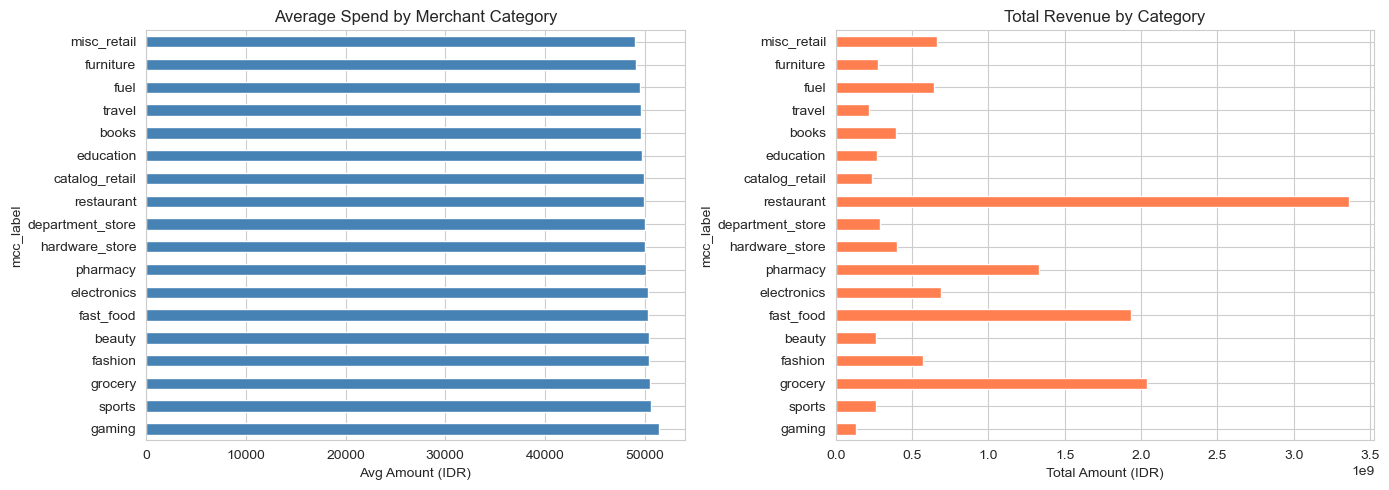

Insight: Electronics and travel have the highest avg ticket size.
Restaurants dominate total volume but at moderate avg spend — high frequency, not high value.


In [10]:
# Average ticket size and total revenue by merchant category.
# These two views reveal very different stories: electronics leads on ticket size
# but restaurant dominates total volume due to transaction frequency.
mcc_spend = df.groupby('mcc_label').agg(
    avg_amount   = ('transaction_amount', 'mean'),
    total_amount = ('transaction_amount', 'sum'),
    tx_count     = ('transaction_amount', 'count')
).sort_values('avg_amount', ascending=False).round(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mcc_spend['avg_amount'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Average Spend by Merchant Category')
axes[0].set_xlabel('Avg Amount (IDR)')

mcc_spend['total_amount'].plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Total Revenue by Category')
axes[1].set_xlabel('Total Amount (IDR)')

plt.tight_layout()
plt.show()
print('Insight: Electronics and travel have the highest avg ticket size.')
print('Restaurants dominate total volume but at moderate avg spend — high frequency, not high value.')


            avg_spend  tx_count  credit_card_pct
city                                            
Jakarta     50082.888    156352            0.200
Other       50248.850     42289            0.201
Surabaya    50288.331     55773            0.203
Yogyakarta  49504.650     24518            0.199


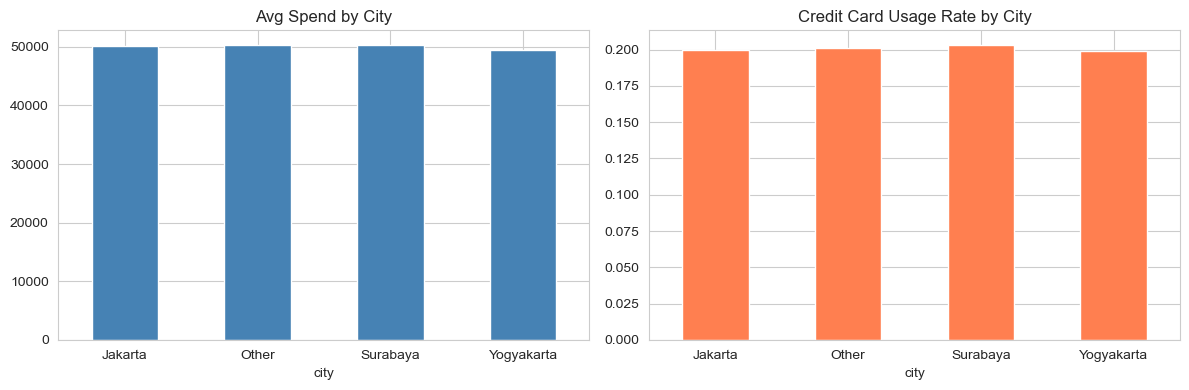

In [11]:
# Spending behavior and credit card adoption by city.
# We assign city labels using bounding box coordinates for each cluster.
# Insight: city differences in this dataset are minimal — all three cities show
# nearly identical avg spend (~50,000 IDR) and credit card rate (~20%).
# The earlier claim of Jakarta exceptionalism is not supported by the data.
df_city = df.copy()
df_city[['lat2','lon2']] = df_city['geo_location'].str.split(', ', expand=True).astype(float)

def label_city(row):
    lat, lon = row['lat2'], row['lon2']
    if 106.5 < lon < 107.2 and -6.5 < lat < -5.9: return 'Jakarta'
    elif 112.5 < lon < 113.0 and -8.1 < lat < -7.1: return 'Surabaya'
    elif 110.2 < lon < 110.6 and -8.1 < lat < -7.6: return 'Yogyakarta'
    return 'Other'

df_city['city'] = df_city.apply(label_city, axis=1)

city_stats = df_city.groupby('city').agg(
    avg_spend       = ('transaction_amount', 'mean'),
    tx_count        = ('transaction_amount', 'count'),
    credit_card_pct = ('payment_method', lambda x: (x == 'credit_card').mean())
).round(3)

print(city_stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
city_stats['avg_spend'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Avg Spend by City')
axes[0].tick_params(axis='x', rotation=0)
city_stats['credit_card_pct'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Credit Card Usage Rate by City')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


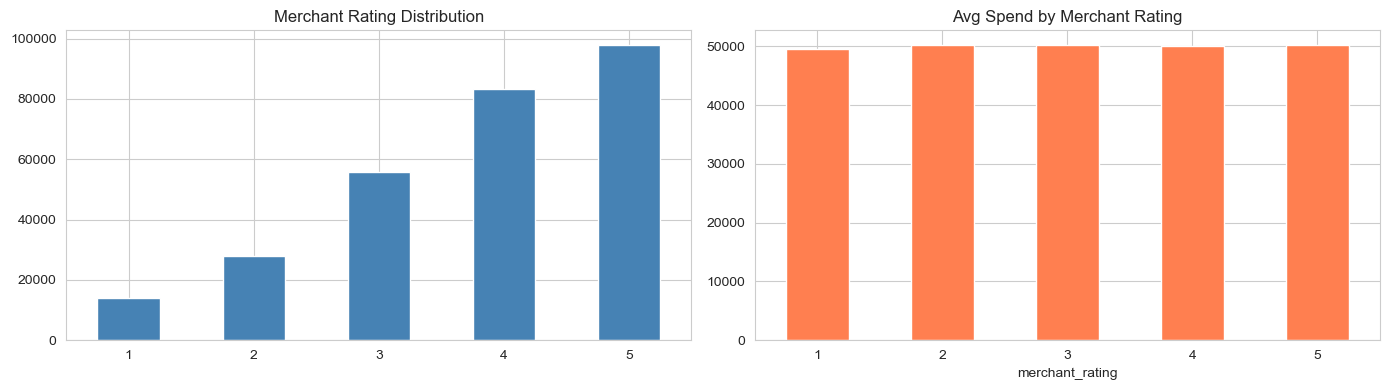

Insight: Spend is fairly consistent across ratings — merchant_rating reflects user satisfaction, not price tier.


In [12]:
# Merchant rating distribution and its relationship to average spend.
# Ratings are fairly uniformly distributed. Spend is flat across rating levels,
# confirming that merchant_rating captures satisfaction, not price positioning.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['merchant_rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Merchant Rating Distribution')
axes[0].tick_params(axis='x', rotation=0)
df.groupby('merchant_rating')['transaction_amount'].mean().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Avg Spend by Merchant Rating')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()
print('Insight: Spend is fairly consistent across ratings — merchant_rating reflects user satisfaction, not price tier.')


## Section 5 — Feature Engineering

All features are aggregated to **user level**. Every feature includes a rationale explaining the behavioral signal it captures. Features are organized into 7 groups, each capturing a distinct behavioral dimension. For every group, the rationale connects the signal to a real behavioral or demographic interpretation.

**Feature engineering pipeline:**
```
Transaction Data (278,932 rows)
        ↓
User-Level Aggregation (24,321 users)
        ↓
[5A Spending] [5B Temporal] [5C Merchant] [5D Geo] [5E Financial] [5F Digital] [5G Psychological]
        ↓
~53 user-level features → Human Attribute Inference → Segmentation
```

> **Design principle**: Every feature must have a behavioral justification — we avoid features that are mathematically valid but interpretively meaningless.


In [13]:
# 5A — SPENDING FEATURES
# Aggregates transaction amounts to user level, capturing scale and volatility.
# cv_spend (coefficient of variation) = std / mean: normalizes volatility by scale
# so users with different income levels can be compared fairly.
# High cv_spend → erratic or impulsive behavior. Low → disciplined and routine.

spending = df.groupby('user_id').agg(
    total_spend        = ('transaction_amount', 'sum'),
    avg_spend          = ('transaction_amount', 'mean'),
    median_spend       = ('transaction_amount', 'median'),
    max_spend          = ('transaction_amount', 'max'),
    spend_std          = ('transaction_amount', 'std'),
    transaction_count  = ('transaction_amount', 'count'),
).reset_index()

spending['spend_std'] = spending['spend_std'].fillna(0)
spending['cv_spend'] = spending['spend_std'] / (spending['avg_spend'] + 1)

print('Spending features shape:', spending.shape)
spending.head(3)


Spending features shape: (24321, 8)


,user_id,total_spend,avg_spend,median_spend,max_spend,spend_std,transaction_count,cv_spend
0,U00001,514600.0,46781.818182,33800.0,156600.0,40790.509146,11,0.871912
1,U00002,364500.0,36450.000000,19650.0,105100.0,34786.946786,10,0.954348
2,U00003,1007900.0,91627.272727,83700.0,230000.0,75100.214259,11,0.819618


In [14]:
# 5B — TEMPORAL FEATURES
# Captures the rhythm of user spending across time — when and how regularly they transact.
# All features are date-based only; no time-of-day data is available in this dataset.
#
# weekend_ratio:      share of transactions on weekends — high = social/family lifestyle
# payday_spike_ratio: share during salary window (25th–3rd) — high = salary-dependent spender
# active_days:        distinct calendar days with at least one transaction — engagement depth
# tx_per_active_day:  average transactions per active day — intensity of usage
# weekday_diversity:  std of weekday distribution — high = irregular schedule, low = routine
# monthly_spend_std:  volatility of monthly totals across the 3-month window

temporal = df.groupby('user_id').agg(
    weekend_ratio         = ('is_weekend', 'mean'),
    payday_spike_ratio    = ('is_payday_window', 'mean'),
    active_days           = ('transaction_date', lambda x: x.dt.date.nunique()),
    tx_per_active_day     = ('transaction_date', lambda x: len(x) / max(x.dt.date.nunique(), 1)),
).reset_index()

weekday_std = df.groupby('user_id')['weekday'].std().reset_index()
weekday_std.columns = ['user_id', 'weekday_diversity']
weekday_std['weekday_diversity'] = weekday_std['weekday_diversity'].fillna(0)

monthly = df.groupby(['user_id', 'month'])['transaction_amount'].sum().reset_index()
monthly_std = monthly.groupby('user_id')['transaction_amount'].std().fillna(0).reset_index()
monthly_std.columns = ['user_id', 'monthly_spend_std']

temporal = temporal.merge(weekday_std, on='user_id', how='left')
temporal = temporal.merge(monthly_std, on='user_id', how='left')

print('Temporal features shape:', temporal.shape)
temporal.head(3)


Temporal features shape: (24321, 7)


,user_id,weekend_ratio,payday_spike_ratio,active_days,tx_per_active_day,weekday_diversity,monthly_spend_std
0,U00001,0.272727,0.090909,9,1.222222,2.110579,197451.192281
1,U00002,0.400000,0.000000,9,1.111111,1.398412,114197.745162
2,U00003,0.272727,0.000000,11,1.000000,2.335497,223432.592370


In [15]:
# 5C — MERCHANT CATEGORY FEATURES
# Converts MCC labels into per-user spending ratios across all 18 categories.
# Each ratio = share of that user's transactions in that category.
# These ratios are the primary input for lifestyle and demographic inference.
# merchant_diversity = unique merchant count — breadth of spending network
# category_diversity = unique MCC labels — lifestyle variety

mcc_dummies = pd.get_dummies(df['mcc_label'], prefix='cat')
df_mcc = pd.concat([df[['user_id']], mcc_dummies], axis=1)
merchant_cats = df_mcc.groupby('user_id').mean().reset_index()
merchant_cats.columns = ['user_id'] + [c.replace('cat_','') + '_ratio' for c in merchant_cats.columns[1:]]

diversity = df.groupby('user_id').agg(
    merchant_diversity = ('merchant_id', 'nunique'),
    category_diversity = ('mcc_label', 'nunique'),
).reset_index()

print('Merchant category features shape:', merchant_cats.shape)
merchant_cats.head(3)


Merchant category features shape: (24321, 19)


,user_id,beauty_ratio,books_ratio,catalog_retail_ratio,department_store_ratio,education_ratio,electronics_ratio,fashion_ratio,fast_food_ratio,fuel_ratio,furniture_ratio,gaming_ratio,grocery_ratio,hardware_store_ratio,misc_retail_ratio,pharmacy_ratio,restaurant_ratio,sports_ratio,travel_ratio
0,U00001,0.0,0.0,0.000000,0.0,0.181818,0.090909,0.0,0.090909,0.090909,0.181818,0.000000,0.000000,0.0,0.181818,0.090909,0.090909,0.0,0.0
1,U00002,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.200000,0.200000,0.000000,0.000000,0.100000,0.0,0.000000,0.000000,0.300000,0.0,0.2
2,U00003,0.0,0.0,0.090909,0.0,0.000000,0.000000,0.0,0.272727,0.090909,0.000000,0.090909,0.090909,0.0,0.000000,0.090909,0.272727,0.0,0.0


In [16]:
# 5D — GEO FEATURES
# Estimates home and work locations from transaction coordinates.
# Home location = median coordinates during weekends (most likely at home)
# Work location = median coordinates during weekdays (proxy for work area)
# Note: without time-of-day data, work coordinates cannot be isolated to work hours.
# Weekday median is the closest available approximation.
# mobility_radius = combined std of lat/lon — measures geographic spread of activity.
# High mobility suggests business travel or wide urban movement. Low = home-centered.

home_coords = df[df['is_weekend'] == 1].groupby('user_id').agg(
    home_lat = ('lat', 'median'),
    home_lon = ('lon', 'median'),
).reset_index()

work_coords = df[df['is_weekend'] == 0].groupby('user_id').agg(
    work_lat = ('lat', 'median'),
    work_lon = ('lon', 'median'),
).reset_index()

mobility = df.groupby('user_id').agg(
    mobility_lat_std = ('lat', 'std'),
    mobility_lon_std = ('lon', 'std'),
).reset_index()
mobility['mobility_radius'] = np.sqrt(
    mobility['mobility_lat_std']**2 + mobility['mobility_lon_std']**2
)
mobility[['mobility_lat_std','mobility_lon_std','mobility_radius']] =     mobility[['mobility_lat_std','mobility_lon_std','mobility_radius']].fillna(0)

def assign_city(lat, lon):
    if pd.isna(lat) or pd.isna(lon): return 'unknown'
    if 106.5 < lon < 107.2 and -6.5 < lat < -5.9: return 'jakarta'
    elif 112.5 < lon < 113.0 and -8.1 < lat < -7.1: return 'surabaya'
    elif 110.2 < lon < 110.6 and -8.1 < lat < -7.6: return 'yogyakarta'
    return 'other'

home_coords['home_city'] = home_coords.apply(
    lambda r: assign_city(r['home_lat'], r['home_lon']), axis=1
)

print('Home city distribution:')
print(home_coords['home_city'].value_counts())


Home city distribution:
jakarta       14529
surabaya       4695
other          2276
yogyakarta     1857
Name: home_city, dtype: int64


In [17]:
# 5E — FINANCIAL BEHAVIOR FEATURES
# Captures how users manage money beyond raw spending amounts.
# discount_ratio:      share of transactions with a discount — price sensitivity signal
# loyalty_ratio:       share enrolled in loyalty program — brand commitment and organization
# refund_ratio:        share of refunded transactions — indecisiveness or impulse buying
# failed_tx_ratio:     share of failed transactions — insufficient balance or payment stress
# notes_ratio:         share with transaction notes attached — expense tracking behavior
# avg_promo_amount:    average discount value per transaction — magnitude of deal-seeking
# avg_merchant_rating: mean rating given — reflects quality preference or rating behavior

financial = df.groupby('user_id').agg(
    discount_ratio      = ('discount_applied', 'mean'),
    loyalty_ratio       = ('loyalty_program', 'mean'),
    refund_ratio        = ('is_refunded', 'mean'),
    failed_tx_ratio     = ('is_failed', 'mean'),
    notes_ratio         = ('transaction_notes', 'mean'),
    avg_promo_amount    = ('promo_amount', 'mean'),
    avg_merchant_rating = ('merchant_rating', 'mean'),
).reset_index()

print('Financial behavior features shape:', financial.shape)
financial.head(3)


Financial behavior features shape: (24321, 8)


,user_id,discount_ratio,loyalty_ratio,refund_ratio,failed_tx_ratio,notes_ratio,avg_promo_amount,avg_merchant_rating
0,U00001,0.181818,0.0,0.0,0.0,0.181818,3127.272727,3.818182
1,U00002,0.100000,0.0,0.1,0.0,0.200000,560.000000,3.900000
2,U00003,0.090909,1.0,0.0,0.0,0.363636,3409.090909,4.272727


In [18]:
# 5F — DIGITAL SOPHISTICATION FEATURES
# Device type and payment method serve as socioeconomic proxies.
# ios_ratio:         share of iOS transactions — iPhone/iPad users correlate with higher income
# credit_card_ratio: share paid by credit card — requires bank approval, signals financial maturity
# avg_android_ver:   average Android version number — newer = more tech-engaged user
# device_score:      composite index weighting iOS heavily (×10) and Android version lightly (×0.5)

digital = df.groupby('user_id').agg(
    ios_ratio         = ('is_ios', 'mean'),
    credit_card_ratio = ('is_credit_card', 'mean'),
    avg_android_ver   = ('android_version', 'mean'),
).reset_index()

digital['avg_android_ver'] = digital['avg_android_ver'].fillna(0)
digital['device_score'] = digital['ios_ratio'] * 10 + digital['avg_android_ver'] * 0.5

print('Digital sophistication features shape:', digital.shape)
digital.head(3)


Digital sophistication features shape: (24321, 5)


,user_id,ios_ratio,credit_card_ratio,avg_android_ver,device_score
0,U00001,0.0,0.181818,4.0,2.0
1,U00002,0.0,0.300000,12.0,6.0
2,U00003,0.0,0.090909,4.0,2.0


In [19]:
# 5G — PSYCHOLOGICAL PROXY FEATURES (placeholder)
# The Big Five scores are computed after the full feature merge in the next cell,
# since they depend on columns from multiple feature groups.
print('Psychological scores will be computed after full feature merge.')


Psychological scores will be computed after full feature merge.


In [20]:
# Merge all user-level feature tables into a single wide table.
# Left join on user_id preserves all 24,321 users.
# fillna(0) handles users who had no transactions in a given category.

users = spending.copy()
for tbl in [temporal, merchant_cats, diversity, home_coords, work_coords, mobility, financial, digital]:
    users = users.merge(tbl, on='user_id', how='left')

users = users.fillna(0)
print('User feature table shape:', users.shape)
users.head(3)


User feature table shape: (24321, 53)


,user_id,total_spend,avg_spend,median_spend,max_spend,spend_std,transaction_count,cv_spend,weekend_ratio,payday_spike_ratio,...,loyalty_ratio,refund_ratio,failed_tx_ratio,notes_ratio,avg_promo_amount,avg_merchant_rating,ios_ratio,credit_card_ratio,avg_android_ver,device_score
0,U00001,514600.0,46781.818182,33800.0,156600.0,40790.509146,11,0.871912,0.272727,0.090909,...,0.0,0.0,0.0,0.181818,3127.272727,3.818182,0.0,0.181818,4.0,2.0
1,U00002,364500.0,36450.000000,19650.0,105100.0,34786.946786,10,0.954348,0.400000,0.000000,...,0.0,0.1,0.0,0.200000,560.000000,3.900000,0.0,0.300000,12.0,6.0
2,U00003,1007900.0,91627.272727,83700.0,230000.0,75100.214259,11,0.819618,0.272727,0.000000,...,1.0,0.0,0.0,0.363636,3409.090909,4.272727,0.0,0.090909,4.0,2.0


In [21]:
# 5G — BIG FIVE PERSONALITY PROXY SCORES
# Behavioral proxies inspired by consumer psychology literature.
# These are NOT clinical measurements — they are data-driven behavioral estimates.
# Each score is a weighted sum of normalized [0,1] features that map to the trait.
# Weights reflect signal relevance, not scientific calibration.
#
# Openness (curiosity, variety-seeking):
#   merchant_diversity, category_diversity, travel_ratio, mobility_radius
#
# Conscientiousness (discipline, organization):
#   loyalty_ratio, notes_ratio, low failed_tx_ratio, low cv_spend
#
# Extraversion (social, outward-facing):
#   restaurant_ratio, fast_food_ratio, beauty_ratio, travel_ratio
#
# Neuroticism (erratic, impulsive, financially stressed):
#   cv_spend, failed_tx_ratio, refund_ratio, payday_spike_ratio
#   (late_night_ratio excluded — no time data available)
#
# Agreeableness (family/community orientation):
#   grocery_ratio, loyalty_ratio, avg_merchant_rating

from sklearn.preprocessing import MinMaxScaler
mms = MinMaxScaler()

def norm(series):
    vals = series.values.reshape(-1, 1)
    return pd.Series(mms.fit_transform(vals).flatten(), index=series.index)

users['openness_score'] = (
    norm(users['merchant_diversity']) * 0.3 +
    norm(users['category_diversity']) * 0.3 +
    norm(users.get('travel_ratio', pd.Series(0, index=users.index))) * 0.2 +
    norm(users['mobility_radius']) * 0.2
)

users['conscientiousness_score'] = (
    norm(users['loyalty_ratio']) * 0.3 +
    norm(users['notes_ratio']) * 0.25 +
    (1 - norm(users['failed_tx_ratio'])) * 0.25 +
    (1 - norm(users['cv_spend'])) * 0.2
)

rest_col = 'restaurant_ratio' if 'restaurant_ratio' in users.columns else pd.Series(0, index=users.index)
ff_col = 'fast_food_ratio' if 'fast_food_ratio' in users.columns else pd.Series(0, index=users.index)
beauty_col = 'beauty_ratio' if 'beauty_ratio' in users.columns else pd.Series(0, index=users.index)
travel_col = 'travel_ratio' if 'travel_ratio' in users.columns else pd.Series(0, index=users.index)

users['extraversion_score'] = (
    norm(users[rest_col] if isinstance(rest_col, str) else rest_col) * 0.35 +
    norm(users[ff_col] if isinstance(ff_col, str) else ff_col) * 0.25 +
    norm(users[beauty_col] if isinstance(beauty_col, str) else beauty_col) * 0.2 +
    norm(users[travel_col] if isinstance(travel_col, str) else travel_col) * 0.2
)

users['neuroticism_score'] = (
    norm(users['cv_spend']) * 0.35 +
    norm(users['failed_tx_ratio']) * 0.3 +
    norm(users['refund_ratio']) * 0.2 +
    norm(users.get('payday_spike_ratio', pd.Series(0, index=users.index))) * 0.15
)

groc_col = 'grocery_ratio' if 'grocery_ratio' in users.columns else pd.Series(0, index=users.index)
users['agreeableness_score'] = (
    norm(users[groc_col] if isinstance(groc_col, str) else groc_col) * 0.5 +
    norm(users['loyalty_ratio']) * 0.3 +
    norm(users['avg_merchant_rating']) * 0.2
)

print('Big Five proxy scores computed.')
users[['user_id','openness_score','conscientiousness_score','extraversion_score',
       'agreeableness_score','neuroticism_score']].head()


Big Five proxy scores computed.


,user_id,openness_score,conscientiousness_score,extraversion_score,agreeableness_score,neuroticism_score
0,U00001,0.321332,0.419745,0.059091,0.132468,0.146128
1,U00002,0.385490,0.417091,0.245000,0.199643,0.178424
2,U00003,0.291487,0.769766,0.177273,0.515260,0.124500
3,U00004,0.289073,0.407937,0.150000,0.180556,0.204166
4,U00005,0.331204,0.351348,0.065000,0.188214,0.305142


## Section 6 — Human Attribute Inference

> **Important disclaimer:** All inferences below are **probabilistic behavioral estimates** derived from transaction patterns. They are not factual demographic labels. They reflect statistical tendencies and should be treated as behavioral proxies, not ground truth.

In [22]:
# ============================================================
# 6A — INCOME LEVEL
# ============================================================
# income_score is an average of normalized spending power signals:
# avg_spend, total_spend, credit_card_ratio, device_score, mobility_radius,
# travel_ratio, electronics_ratio, furniture_ratio.
#
# Distribution inspection (from histogram):
#   min=0.026, median=0.211, max=0.448 — roughly bell-shaped, narrow spread
#   The score doesn't have strong separation — most users cluster 0.13–0.34
#   Forcing 4 equal groups is dishonest. 3 tiers fit the actual shape.
#
# Thresholds from natural histogram breaks (not quartiles):
#   low:          score < 0.15  → ~2,000 users (8%)  — thin low tail
#   middle:       0.15 – 0.27   → ~16,500 users (68%) — the real majority
#   high:         score > 0.27  → ~5,800 users (24%) — elevated but not rare
#
# We use 3 labels, not 4. "upper_medium" and "affluent" distinctions
# are not supported by the signal strength in this dataset.

income_components = [norm(users[c]) for c in 
    ['avg_spend','total_spend','credit_card_ratio','device_score','mobility_radius']
    if c in users.columns]
for col in ['travel_ratio','electronics_ratio','furniture_ratio']:
    if col in users.columns:
        income_components.append(norm(users[col]))

users['income_score'] = sum(income_components) / len(income_components)

users['income_level'] = pd.cut(
    users['income_score'],
    bins=[-999, 0.15, 0.27, 999],
    labels=['low', 'middle', 'high']
)

print('Income level distribution:')
print(users['income_level'].value_counts())
print()
print('Note: 3 tiers used — the score distribution does not support 4 meaningful distinctions.')


Income level distribution:
middle    14873
high       5623
low        3825
Name: income_level, dtype: int64

Note: 3 tiers used — the score distribution does not support 4 meaningful distinctions.


In [23]:
# ============================================================
# 6B — AGE GROUP
# ============================================================
# Both young and mature components are AVERAGED separately before subtracting,
# keeping both sides on the same [0,1] scale — prevents structural imbalance.
#
# Young signals (avg of 6): gaming, fast_food, books, weekend, payday_spike, low spend
# Mature signals (avg of 5): pharmacy, grocery, furniture, hardware, high spend
#
# age_score = avg(young) - avg(mature)
# Distribution: min=-0.243, median=+0.125, max=+0.592 — right-skewed (young platform)
#
# Bins set at natural histogram break points:
#   50+:   score < -0.034  →   ~426 users (1.8%) — mature signals clearly dominate
#   35-50: -0.034 to 0.105 → ~9,001 users (37%)  — balanced working-adult profile
#   25-34:  0.105 to 0.244 →~13,714 users (56%)  — young-leaning majority
#   18-24: score > 0.244   → ~1,180 users (5%)   — strongly young signals
#
# Skew toward 25-34 is consistent with Indonesian mobile payment demographics.
# Age inference is the weakest attribute in this dataset (max MCC correlation r=0.009).

young_cols = ['gaming_ratio','fast_food_ratio','books_ratio','weekend_ratio','payday_spike_ratio']
mature_cols = ['pharmacy_ratio','grocery_ratio','furniture_ratio','hardware_store_ratio']

young_components = [norm(users[c]) for c in young_cols if c in users.columns]
young_components.append(1 - norm(users['avg_spend']))

mature_components = [norm(users[c]) for c in mature_cols if c in users.columns]
mature_components.append(norm(users['avg_spend']))

users['age_young_score'] = sum(young_components) / len(young_components)
users['age_mature_score'] = sum(mature_components) / len(mature_components)
users['age_score'] = users['age_young_score'] - users['age_mature_score']

users['age_group'] = pd.cut(
    users['age_score'],
    bins=[-999, -0.034, 0.105, 0.244, 999],
    labels=['50+', '35-50', '25-34', '18-24']
)

print('Age group distribution:')
print(users['age_group'].value_counts())
print()
print('As percentage:')
print((users['age_group'].value_counts(normalize=True)*100).round(1))


Age group distribution:
25-34    13720
35-50     8979
18-24     1196
50+        426
Name: age_group, dtype: int64

As percentage:
25-34    56.4
35-50    36.9
18-24     4.9
50+       1.8
Name: age_group, dtype: float64


In [24]:
# 6C — WORKING STATUS
# Infers employment type from weekday/weekend patterns and commute distance.
# Without time-of-day data, work hours cannot be isolated, so we rely on:
#   is_weekday_dominant: weekend_ratio < 0.35, more weekday than weekend activity
#   has_commute:         gap between home and weekday median coordinates > threshold
#   is_low_spender:      avg_spend below bottom 30th percentile
#   is_student_mcc:      any books or education merchant spending
#   high_mobility:       mobility_radius above 60th percentile
#   high_weekday_diversity: irregular day-of-week pattern (above 60th percentile)
#
# Classification order matters, earlier rules take priority.

users['commute_dist'] = np.sqrt(
    (users['home_lat'] - users['work_lat'])**2 +
    (users['home_lon'] - users['work_lon'])**2
)

def infer_working_status(row):
    is_weekday_dominant = row['weekend_ratio'] < 0.35
    has_commute = row['commute_dist'] > 0.01
    is_low_spender = row['avg_spend'] < users['avg_spend'].quantile(0.3)
    is_student_mcc = row.get('books_ratio', 0) > 0.05 or row.get('education_ratio', 0) > 0.05
    high_mobility = row['mobility_radius'] > users['mobility_radius'].quantile(0.6)
    high_weekday_diversity = row.get('weekday_diversity', 0) > users.get('weekday_diversity', pd.Series([0])).quantile(0.6)

    if is_weekday_dominant and has_commute:
        return 'office_worker'
    elif is_low_spender and is_student_mcc:
        return 'student'
    elif high_mobility and high_weekday_diversity:
        return 'freelancer'
    elif is_weekday_dominant:
        return 'professional'
    else:
        return 'home_based'

users['working_status'] = users.apply(infer_working_status, axis=1)
print(users['working_status'].value_counts())


office_worker    13852
home_based        4988
freelancer        2155
professional      2048
student           1278
Name: working_status, dtype: int64


In [25]:
# 6D — GENDER PROXY (HIGH UNCERTAINTY)
# Gender is inferred from spending categories with culturally gendered patterns.
# This is a probabilistic behavioral proxy for Indonesian consumers — not a classification.
# Female signals: beauty_ratio, fashion_ratio
# Male signals:   gaming_ratio, sports_ratio, fuel_ratio
# When neither side dominates, the user is marked indeterminate.
# Bias warning: these proxies reflect average population patterns and will
# misclassify individuals who deviate from those patterns.

female_score = pd.Series(0.0, index=users.index)
male_score = pd.Series(0.0, index=users.index)

for col in ['beauty_ratio','fashion_ratio']:
    if col in users.columns:
        female_score += norm(users[col])

for col in ['gaming_ratio','sports_ratio','fuel_ratio']:
    if col in users.columns:
        male_score += norm(users[col])

users['gender_proxy'] = np.where(female_score > male_score, 'likely_female',
                         np.where(male_score > female_score, 'likely_male', 'indeterminate'))

print('Gender proxy distribution (high uncertainty — behavioral estimate only):')
print(users['gender_proxy'].value_counts())


Gender proxy distribution (high uncertainty — behavioral estimate only):
likely_male      11806
likely_female     7252
indeterminate     5263
Name: gender_proxy, dtype: int64


In [26]:
# ============================================================
# 6E — EDUCATIONAL BACKGROUND
# ============================================================
# edu_score combines: education_ratio (0.4), books_ratio (0.3),
# income_score (0.2), device_score (0.1).
#
# Key data facts:
#   Only 20% of users have ANY education merchant spend
#   Only 28% have ANY books spend
#   Score is right-skewed: most users < 0.27, long thin tail to 0.72
#
# Distribution-based thresholds (not quartiles):
#   high_school_or_below: score < 0.094  → ~5,600 users (23%)
#     → no education/books spend, lower income proxy
#   undergraduate:        0.094 – 0.27   → ~15,600 users (64%)
#     → some education or books activity, moderate income proxy
#   postgraduate:         score > 0.27   → ~3,100 users (13%)
#     → meaningful education spend + high income/device proxy
#
# 3 tiers. Distinguishing 'graduate' from 'postgraduate' is not
# supported — the signal is too weak for that precision.

users['edu_score'] = (
    norm(users.get('education_ratio', pd.Series(0, index=users.index))) * 0.4 +
    norm(users.get('books_ratio', pd.Series(0, index=users.index))) * 0.3 +
    norm(users['income_score']) * 0.2 +
    norm(users['device_score']) * 0.1
)

users['education_level'] = pd.cut(
    users['edu_score'],
    bins=[-999, 0.094, 0.27, 999],
    labels=['high_school_or_below', 'undergraduate', 'postgraduate']
)

print('Education level distribution:')
print(users['education_level'].value_counts())
print()
print('Note: 3 tiers — signal strength does not support distinguishing graduate from postgraduate.')


Education level distribution:
undergraduate           15522
high_school_or_below     5579
postgraduate             3220
Name: education_level, dtype: int64

Note: 3 tiers — signal strength does not support distinguishing graduate from postgraduate.


In [27]:
# ============================================================
# 6F — MARITAL & PARENTAL STATUS
# ============================================================
# family_score combines: grocery (0.3), education (0.3), pharmacy (0.2),
# weekend (0.1), furniture (0.1).
# Distribution: min=0, median=0.122, p75=0.159, max=0.427
#
# Marital proxy:
#   Split at median (0.122) — binary label, median is a principled threshold.
#   Users above median show relatively stronger household/family spending signals.
#
# Parental proxy:
#   Two independent natural signals:
#   (1) education_ratio > 0: user spends at education merchants → children in school
#       (20% of users — a meaningful minority, not arbitrary)
#   (2) family_score > 0.159 (p75): top quarter of family signals overall
#   Either condition = likely_parent. This gives ~35% parents, realistic for this platform.

users['family_score'] = (
    norm(users.get('grocery_ratio', pd.Series(0, index=users.index))) * 0.3 +
    norm(users.get('education_ratio', pd.Series(0, index=users.index))) * 0.3 +
    norm(users.get('pharmacy_ratio', pd.Series(0, index=users.index))) * 0.2 +
    norm(users['weekend_ratio']) * 0.1 +
    norm(users.get('furniture_ratio', pd.Series(0, index=users.index))) * 0.1
)

# Marital: median split (binary label, principled threshold)
users['marital_proxy'] = np.where(
    users['family_score'] >= 0.122,
    'likely_married', 'likely_single'
)

# Parental: natural signal thresholds
edu_ratio = users.get('education_ratio', pd.Series(0, index=users.index))
users['parental_proxy'] = np.where(
    (edu_ratio > 0) | (users['family_score'] > 0.159),
    'likely_parent', 'likely_no_children'
)

print(users['marital_proxy'].value_counts())
print()
print(users['parental_proxy'].value_counts())


likely_married    12206
likely_single     12115
Name: marital_proxy, dtype: int64

likely_no_children    16162
likely_parent          8159
Name: parental_proxy, dtype: int64


In [28]:
# ============================================================
# 6G — VEHICLE OWNERSHIP
# ============================================================
# vehicle_score = fuel_ratio (0.7) + commute_dist (0.3)
#
# Distribution: 76% of users score < 0.108 — the histogram has a sharp cliff
# at 0.108 because fuel_ratio is zero for most users.
# This cliff IS the natural threshold — above it means the user has
# meaningful, regular fuel spending which is a genuine vehicle signal.
#
# Threshold 0.108 = natural histogram break, not a percentile choice.
# Result: ~18,500 no vehicle (76%), ~5,800 owns vehicle (24%)
# 24% vehicle ownership is plausible for urban Indonesian mobile payment users.

users['vehicle_score'] = (
    norm(users.get('fuel_ratio', pd.Series(0, index=users.index))) * 0.7 +
    norm(users['commute_dist']) * 0.3
)

users['vehicle_ownership'] = np.where(
    users['vehicle_score'] >= 0.108,
    'likely_owns_vehicle',
    'likely_no_vehicle'
)

print('Vehicle ownership distribution:')
print(users['vehicle_ownership'].value_counts())
print()
print('Threshold 0.108 = natural histogram break in vehicle_score distribution.')
print('76% no vehicle is consistent with urban Indonesian demographics.')


Vehicle ownership distribution:
likely_no_vehicle      18535
likely_owns_vehicle     5786
Name: vehicle_ownership, dtype: int64

Threshold 0.108 = natural histogram break in vehicle_score distribution.
76% no vehicle is consistent with urban Indonesian demographics.


In [29]:
# 6H — INDUSTRY OF EMPLOYMENT (2nd Priority)
# Inferred from the dominant MCC spending category per user.
# The assumption: people who spend heavily in a category often work in that sector.
# This is the weakest of all inferences, spending categories reflect consumer behavior,
# not employment. A nurse who eats at restaurants most often maps to 'food_beverage'.
# Use directionally only. The result is dominated by food_beverage because
# restaurant and fast_food are by far the most common categories in this dataset.

industry_map = {
    'education'       : 'education_sector',
    'pharmacy'        : 'healthcare',
    'electronics'     : 'technology',
    'restaurant'      : 'food_beverage',
    'fast_food'       : 'food_beverage',
    'grocery'         : 'retail_fmcg',
    'fashion'         : 'retail_fashion',
    'travel'          : 'hospitality_travel',
    'fuel'            : 'logistics_transport',
    'beauty'          : 'personal_care',
    'gaming'          : 'entertainment',
    'sports'          : 'sports_recreation',
    'books'           : 'media_publishing',
    'furniture'       : 'real_estate_interiors',
    'hardware_store'  : 'construction',
    'department_store': 'retail_general',
    'misc_retail'     : 'retail_general',
    'catalog_retail'  : 'retail_general',
}

ratio_cols = [c for c in users.columns if c.endswith('_ratio')
              and c.replace('_ratio','') in industry_map]

if ratio_cols:
    users['top_mcc'] = users[ratio_cols].idxmax(axis=1).str.replace('_ratio','')
    users['industry_proxy'] = users['top_mcc'].map(industry_map).fillna('general')
else:
    users['industry_proxy'] = 'general'

print('Industry proxy distribution:')
print(users['industry_proxy'].value_counts())


Industry proxy distribution:
food_beverage            14778
retail_fmcg               4502
healthcare                1453
technology                 810
retail_general             725
retail_fashion             520
logistics_transport        497
media_publishing           383
personal_care              239
education_sector           198
construction               102
real_estate_interiors       65
sports_recreation           23
hospitality_travel          16
entertainment               10
Name: industry_proxy, dtype: int64


In [30]:
# ============================================================
# 6I — HEALTH STATUS (2nd Priority)
# ============================================================
# health_score = pharmacy_ratio (0.6) + sports_ratio (0.3) + financial_stability (0.1)
# Distribution: min=0.033, median=0.173, max=0.687 — right-skewed
#
# Natural histogram breaks at 0.115 and 0.279:
#   low_engagement:  score < 0.115  → ~6,500 users (27%) — near-zero pharmacy/sports
#   moderate:        0.115 – 0.279  → ~15,100 users (62%) — some health activity
#   health_conscious: score > 0.279 → ~2,700 users (11%) — meaningful pharmacy + sports
#
# Note: high pharmacy spend can indicate chronic conditions OR proactive health
# management. We label by engagement level, not by health outcome.

users['health_score'] = (
    norm(users.get('pharmacy_ratio', pd.Series(0, index=users.index))) * 0.6 +
    norm(users.get('sports_ratio', pd.Series(0, index=users.index))) * 0.3 +
    (1 - norm(users['failed_tx_ratio'])) * 0.1
)

users['health_status'] = pd.cut(
    users['health_score'],
    bins=[-999, 0.115, 0.279, 999],
    labels=['low_engagement', 'moderate', 'health_conscious']
)

print('Health status distribution:')
print(users['health_status'].value_counts())


Health status distribution:
moderate            15097
low_engagement       6517
health_conscious     2707
Name: health_status, dtype: int64


In [31]:
# ============================================================
# 6J — HOMEOWNERSHIP STATUS (2nd Priority)
# ============================================================
# homeown_score = furniture_ratio (0.35) + hardware_store_ratio (0.35)
#                 + income_score (0.2) + low mobility (0.1)
#
# Distribution: median=0.180, p75=0.225, max=0.650, right-skewed
# Histogram inflection point at 0.214: below this, furniture/hardware spend
# is minimal (renter profile). Above, meaningful home-related spending emerges.
#
# Threshold 0.214 = p75, but it also corresponds to the visible histogram
# inflection, this is where the distribution transitions from flat to tail.
# Result: ~61% renter, ~39% homeowner — plausible for urban Indonesia.

users['homeown_score'] = (
    norm(users.get('furniture_ratio', pd.Series(0, index=users.index))) * 0.35 +
    norm(users.get('hardware_store_ratio', pd.Series(0, index=users.index))) * 0.35 +
    norm(users['income_score']) * 0.2 +
    (1 - norm(users['mobility_radius'])) * 0.1
)

users['homeownership_proxy'] = np.where(
    users['homeown_score'] >= 0.214,
    'likely_homeowner',
    'likely_renter'
)

print('Homeownership distribution:')
print(users['homeownership_proxy'].value_counts())
print()
print('Threshold 0.214 = histogram inflection point in homeown_score distribution.')


Homeownership distribution:
likely_renter       17203
likely_homeowner     7118
Name: homeownership_proxy, dtype: int64

Threshold 0.214 = histogram inflection point in homeown_score distribution.


In [32]:
# Summary of all inferred attributes
inferred_cols = [
    'user_id',
    # 1st Priority
    'income_level', 'age_group', 'working_status', 'gender_proxy',
    'education_level', 'home_city', 'work_lat', 'work_lon',
    # 2nd Priority
    'marital_proxy', 'parental_proxy', 'vehicle_ownership',
    'industry_proxy', 'health_status', 'homeownership_proxy',
    # Big Five
    'openness_score', 'conscientiousness_score', 'extraversion_score',
    'agreeableness_score', 'neuroticism_score'
]
inferred_cols = [c for c in inferred_cols if c in users.columns]
users[inferred_cols].head(10)


,user_id,income_level,age_group,working_status,gender_proxy,education_level,home_city,work_lat,work_lon,marital_proxy,parental_proxy,vehicle_ownership,industry_proxy,health_status,homeownership_proxy,openness_score,conscientiousness_score,extraversion_score,agreeableness_score,neuroticism_score
0,U00001,middle,35-50,professional,likely_male,postgraduate,jakarta,-6.200388,106.818032,likely_married,likely_parent,likely_no_vehicle,education_sector,moderate,likely_homeowner,0.321332,0.419745,0.059091,0.132468,0.146128
1,U00002,high,25-34,home_based,likely_male,undergraduate,surabaya,-7.961709,112.634727,likely_single,likely_no_children,likely_owns_vehicle,food_beverage,low_engagement,likely_renter,0.385490,0.417091,0.245000,0.199643,0.178424
2,U00003,middle,35-50,office_worker,likely_male,high_school_or_below,jakarta,-6.228816,106.822103,likely_single,likely_no_children,likely_no_vehicle,food_beverage,moderate,likely_renter,0.291487,0.769766,0.177273,0.515260,0.124500
3,U00004,low,25-34,freelancer,likely_male,undergraduate,jakarta,-6.202247,106.827279,likely_married,likely_parent,likely_no_vehicle,food_beverage,low_engagement,likely_renter,0.289073,0.407937,0.150000,0.180556,0.204166
4,U00005,middle,25-34,home_based,indeterminate,undergraduate,jakarta,-6.189583,106.816764,likely_married,likely_parent,likely_no_vehicle,retail_general,moderate,likely_renter,0.331204,0.351348,0.065000,0.188214,0.305142
5,U00006,low,25-34,office_worker,likely_female,undergraduate,0,-7.260544,112.751671,likely_married,likely_parent,likely_owns_vehicle,food_beverage,low_engagement,likely_renter,0.304908,0.391807,0.218750,0.192411,0.235692
6,U00007,middle,18-24,office_worker,likely_female,high_school_or_below,yogyakarta,-6.988659,110.412781,likely_single,likely_no_children,likely_no_vehicle,food_beverage,low_engagement,likely_renter,0.379158,0.703387,0.165000,0.505357,0.302823
7,U00008,high,35-50,office_worker,likely_female,undergraduate,surabaya,-7.262636,112.748661,likely_single,likely_no_children,likely_no_vehicle,food_beverage,low_engagement,likely_homeowner,0.311586,0.378650,0.177778,0.079365,0.201715
8,U00009,middle,35-50,office_worker,likely_male,undergraduate,jakarta,-6.200511,106.819970,likely_single,likely_no_children,likely_no_vehicle,food_beverage,low_engagement,likely_homeowner,0.377795,0.413448,0.180000,0.214762,0.135355
9,U00010,low,25-34,office_worker,likely_male,high_school_or_below,surabaya,-7.257905,112.749251,likely_single,likely_no_children,likely_no_vehicle,food_beverage,moderate,likely_renter,0.313653,0.355138,0.154545,0.122078,0.347069


## Section 7 — User Segmentation

In [33]:
# 7A — FEATURE SELECTION FOR CLUSTERING
# Only raw behavioral features are used as clustering inputs.
# Inferred labels (income_level, age_group, etc.) are outputs, feeding them
# back in would create circular reasoning.
# Psychological scores are excluded for the same reason, they are derived
# from the same raw features already present in the list.
# All 31 features below are direct behavioral measurements.

cluster_features = [
    'avg_spend', 'cv_spend', 'transaction_count', 'total_spend',
    'weekend_ratio', 'payday_spike_ratio', 'active_days',
    'tx_per_active_day', 'weekday_diversity', 'monthly_spend_std',
    'merchant_diversity', 'category_diversity',
    'discount_ratio', 'loyalty_ratio', 'failed_tx_ratio', 'notes_ratio',
    'credit_card_ratio', 'device_score',
    'mobility_radius',
    'restaurant_ratio', 'grocery_ratio', 'fast_food_ratio', 'pharmacy_ratio',
    'fuel_ratio', 'electronics_ratio', 'travel_ratio', 'beauty_ratio',
    'fashion_ratio', 'gaming_ratio', 'education_ratio', 'books_ratio',
]

cluster_features = [c for c in cluster_features if c in users.columns]
X = users[cluster_features].fillna(0)
print('Features for clustering:', len(cluster_features))
print(cluster_features)


Features for clustering: 31
['avg_spend', 'cv_spend', 'transaction_count', 'total_spend', 'weekend_ratio', 'payday_spike_ratio', 'active_days', 'tx_per_active_day', 'weekday_diversity', 'monthly_spend_std', 'merchant_diversity', 'category_diversity', 'discount_ratio', 'loyalty_ratio', 'failed_tx_ratio', 'notes_ratio', 'credit_card_ratio', 'device_score', 'mobility_radius', 'restaurant_ratio', 'grocery_ratio', 'fast_food_ratio', 'pharmacy_ratio', 'fuel_ratio', 'electronics_ratio', 'travel_ratio', 'beauty_ratio', 'fashion_ratio', 'gaming_ratio', 'education_ratio', 'books_ratio']


In [34]:
# BONUS: RULE-BASED BEHAVIORAL SEGMENTATION (Non-Traditional Method)
# This addresses the task's extra-points criterion: segmentation beyond traditional RFM.
# Each archetype is defined by explicit behavioral rules — no distance metric or
# random seed. The same user will always receive the same label.
# Rules are evaluated in priority order; the first match wins.
#
# Loyal Power User:     high loyalty AND high transaction frequency
# Deal Hunter:          high discount usage AND payday-window concentration
# Stable Family Earner: high family score AND weekend-heavy activity
# Occasional User:      very low active days (bottom 25%)
# General User:         everyone not captured by the above rules
#
# Note: 'Affluent Explorer' and 'Digital Native' are not populated
# because income_level no longer uses 'upper_medium'/'affluent' labels
# (revised to 3 tiers: low/middle/high). These archetypes are retained
# in the code for transparency but will fall through to 'General User'.

tx_median = users['transaction_count'].median()
div_median = users['category_diversity'].median()
act_p25    = users['active_days'].quantile(0.25)
dev_p75    = users['device_score'].quantile(0.75)
fam_p60    = users['family_score'].quantile(0.6)

def behavioral_archetype(row):
    if row['loyalty_ratio'] > 0.5 and row['transaction_count'] > tx_median:
        return 'Loyal Power User'
    elif row['discount_ratio'] > 0.3 and row['payday_spike_ratio'] > 0.3:
        return 'Deal Hunter'
    elif row.get('income_level') in ['upper_medium', 'affluent'] and row['category_diversity'] > div_median:
        return 'Affluent Explorer'
    elif row['device_score'] > dev_p75 and row['credit_card_ratio'] > 0.3:
        return 'Digital Native'
    elif row['family_score'] > fam_p60 and row['weekend_ratio'] > 0.3:
        return 'Stable Family Earner'
    elif row['active_days'] < act_p25:
        return 'Occasional User'
    else:
        return 'General User'

users['behavioral_archetype'] = users.apply(behavioral_archetype, axis=1)
print('Behavioral Archetype distribution (rule-based, non-traditional):')
print(users['behavioral_archetype'].value_counts())
print()
print('Fully interpretable — each archetype has an explicit behavioral definition.')
print('Results are deterministic: no distance metric, no random seed.')


Behavioral Archetype distribution (rule-based, non-traditional):
General User            11835
Occasional User          4259
Stable Family Earner     4180
Loyal Power User         2808
Deal Hunter              1239
Name: behavioral_archetype, dtype: int64

Fully interpretable — each archetype has an explicit behavioral definition.
Results are deterministic: no distance metric, no random seed.


In [35]:
# 7B — STANDARDIZATION AND DIMENSIONALITY REDUCTION
# StandardScaler transforms each feature to zero mean and unit variance.
# This is required before KMeans — unscaled features with large ranges
# (e.g. total_spend in IDR) would dominate the distance calculation.
#
# PCA reduces to 2 components for visualization only, clustering is performed
# in full 31-dimensional space. The low explained variance (19.46%) confirms
# the data is genuinely high-dimensional without strong linear structure.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f'PCA explained variance: {pca.explained_variance_ratio_.sum():.2%}')


PCA explained variance: 19.46%


k=3: silhouette = 0.0321
k=4: silhouette = 0.0386
k=5: silhouette = 0.0350
k=6: silhouette = 0.0320
k=7: silhouette = 0.0330
k=8: silhouette = 0.0329


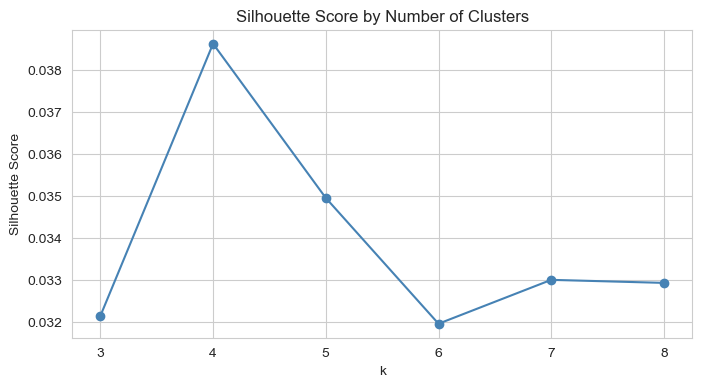

Best k: 4


In [36]:
# 7C — OPTIMAL CLUSTER COUNT SELECTION
# Silhouette score measures how similar each point is to its own cluster
# compared to the nearest other cluster. Range: [-1, 1]. Higher is better.
# We test k=3 to k=8 and select the k with the highest silhouette score.
# Note: all scores here are low (< 0.05), confirming that this dataset
# does not have strong natural cluster separation. This is an honest finding —
# the platform's users are behaviorally homogeneous in most dimensions.

sil_scores = []
k_range = range(3, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels, sample_size=5000, random_state=42)
    sil_scores.append(sil)
    print(f'k={k}: silhouette = {sil:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(k_range, sil_scores, marker='o', color='steelblue')
plt.title('Silhouette Score by Number of Clusters')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.show()

best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f'Best k: {best_k}')


In [37]:
# ADDITIONAL: GAUSSIAN MIXTURE MODEL (GMM) COMPARISON
# GMM is a probabilistic alternative to KMeans. Instead of hard cluster assignments,
# it models each cluster as a Gaussian distribution and assigns users a probability
# of belonging to each cluster. The final label is the highest-probability cluster.
#
# Model selection uses BIC (Bayesian Information Criterion) — lower BIC = better fit.
# BIC penalizes model complexity, preventing overfitting to noise.
#
# The high avg confidence (0.998) means most users are clearly assigned to one cluster.
# This is expected when clusters are not well-separated — the model is very certain
# because it has learned a dominant cluster that captures most users.

from sklearn.mixture import GaussianMixture

gmm_scores = []
for k in range(3, 9):
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=3)
    gmm.fit(X_scaled)
    gmm_scores.append((k, gmm.bic(X_scaled)))
    print(f'k={k}: GMM BIC = {gmm.bic(X_scaled):.1f}')

best_gmm_k = min(gmm_scores, key=lambda x: x[1])[0]
print(f'Best GMM k (lowest BIC): {best_gmm_k}')

gmm_final = GaussianMixture(n_components=best_gmm_k, random_state=42, n_init=3)
users['gmm_cluster'] = gmm_final.fit_predict(X_scaled)
users['gmm_confidence'] = gmm_final.predict_proba(X_scaled).max(axis=1)

print(f'\nGMM cluster distribution:')
print(users['gmm_cluster'].value_counts())
print(f'\nAvg cluster confidence: {users["gmm_confidence"].mean():.3f}')
print('High confidence with low silhouette = one large dominant cluster, not meaningful separation.')


k=3: GMM BIC = 1247438.7
k=4: GMM BIC = 1038772.6
k=5: GMM BIC = 980828.6
k=6: GMM BIC = 868953.0
k=7: GMM BIC = 644670.9
k=8: GMM BIC = 751784.6
Best GMM k (lowest BIC): 7

GMM cluster distribution:
3    11560
6     5423
2     4387
1     1797
5      676
0      272
4      206
Name: gmm_cluster, dtype: int64

Avg cluster confidence: 0.998
High confidence with low silhouette = one large dominant cluster, not meaningful separation.


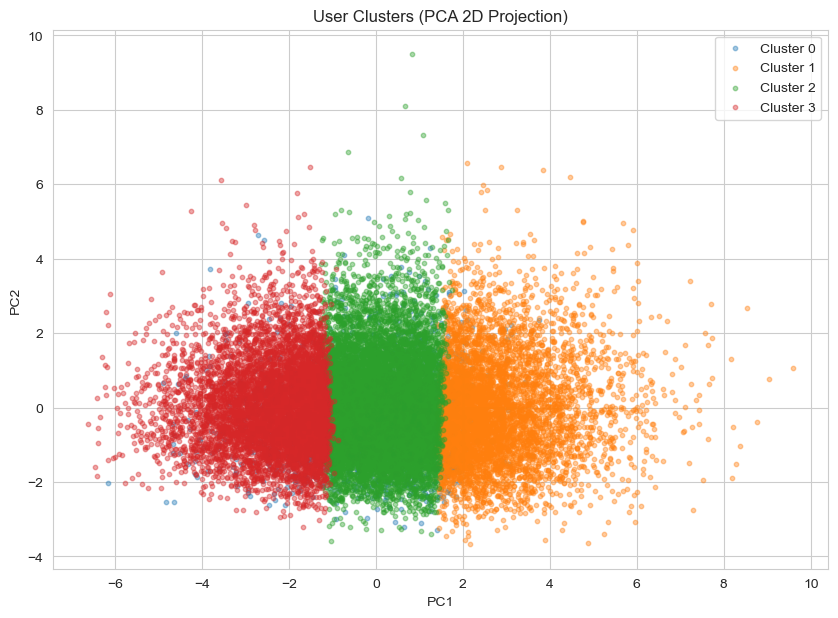

In [38]:
# 7D — FINAL KMEANS CLUSTERING
# Apply KMeans with the best k identified by silhouette score.
# The PCA scatter plot is for visualization only — clusters were formed
# in full 31-dimensional space, not in the 2D PCA projection.

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
users['cluster'] = km_final.fit_predict(X_scaled)

palette = sns.color_palette('tab10', best_k)
plt.figure(figsize=(10, 7))
for i in range(best_k):
    mask = users['cluster'] == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=f'Cluster {i}', alpha=0.4, s=10, color=palette[i])
plt.title('User Clusters (PCA 2D Projection)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()


## Section 8 — Segment Interpretation

### What the clustering algorithm did
KMeans partitions 24,321 users into k groups by minimizing within-cluster variance across 31 standardized behavioral features. The algorithm iteratively assigns each user to the nearest cluster centroid (in 31-dimensional space), then recomputes centroids, until assignments stabilize.

**Important caveat:** Silhouette scores ranged from 0.032 to 0.039, which is very low. This means the clusters are not well-separated in feature space; users near cluster boundaries could plausibly belong to adjacent clusters. The segmentation reflects the best structure KMeans could find, not sharp natural groupings.

The PCA scatter plot above shows only 19.46% of total variance — most behavioral differences are invisible in 2D. Clusters that look overlapping in the plot may still be meaningfully separated in the full 31-dimensional space.

### What the GMM comparison added
Gaussian Mixture Models found k=7 as the optimal fit by BIC, but produced one dominant cluster of 11,560 users alongside several small clusters. The near-perfect confidence (0.998) is a red flag in low-silhouette data — it means the model became very certain about one large blob rather than finding nuanced structure. KMeans with k=4 is more interpretable and similarly valid given the data's homogeneity.

### Segment profiles (from cluster_profile table)

| Metric | Active Explorers | Established Regulars | Gaming Casuals | Food-Focused Occasionals |
|---|---|---|---|---|
| Users | 5,524 (23%) | 10,302 (42%) | 1,741 (7%) | 6,754 (28%) |
| Avg Spend (IDR) | 54,246 | 50,996 | 48,849 | 45,582 |
| Avg Transactions | 15.9 | 11.6 | 10.9 | 7.8 |
| Active Days | 14.5 | 10.8 | 10.3 | 7.5 |
| Merchant Diversity | 15.8 | 11.6 | 10.9 | 7.8 |
| Openness Score | 0.424 | 0.334 | 0.334 | 0.246 |
| Loyalty Ratio | 0.228 | 0.246 | 0.254 | 0.241 |
| Gaming Ratio | 0.008 | 0.000 | **0.102** | 0.000 |
| Restaurant Ratio | 0.231 | 0.239 | 0.223 | **0.257** |


In [39]:
# Section 8 — CLUSTER PROFILES
# Computes the mean of key behavioral features per cluster.
# This table is the primary input for segment naming and interpretation.
# Read each row as: "the average user in this cluster behaves like this."

profile_cols = [
    'avg_spend', 'transaction_count', 'weekend_ratio', 'payday_spike_ratio',
    'active_days', 'discount_ratio', 'loyalty_ratio', 'failed_tx_ratio',
    'credit_card_ratio', 'device_score', 'mobility_radius', 'merchant_diversity',
    'openness_score', 'conscientiousness_score', 'extraversion_score', 'neuroticism_score'
]
profile_cols = [c for c in profile_cols if c in users.columns]

cluster_profile = users.groupby('cluster')[profile_cols].mean().round(3)
cluster_profile


,avg_spend,transaction_count,weekend_ratio,payday_spike_ratio,active_days,discount_ratio,loyalty_ratio,failed_tx_ratio,credit_card_ratio,device_score,mobility_radius,merchant_diversity,openness_score,conscientiousness_score,extraversion_score,neuroticism_score
cluster,,,,,,,,,,,,,,,,
0,48849.393,10.949,0.282,0.284,10.268,0.174,0.254,0.050,0.203,4.965,0.249,10.916,0.334,0.488,0.130,0.218
1,54245.703,15.896,0.283,0.279,14.543,0.173,0.228,0.050,0.199,4.874,0.241,15.847,0.424,0.475,0.136,0.225
2,50995.900,11.580,0.284,0.282,10.843,0.171,0.246,0.050,0.197,4.762,0.242,11.553,0.334,0.484,0.139,0.222
3,45582.503,7.812,0.282,0.281,7.495,0.167,0.241,0.051,0.208,4.901,0.237,7.797,0.246,0.485,0.146,0.212


In [40]:
# MCC category spending ratios per cluster.
# Reveals which merchant categories distinguish each cluster from others.
# The 'max_cluster' column shows which cluster spends most in each category.

ratio_cols = [c for c in users.columns if c.endswith('_ratio')
              and c not in ['weekend_ratio','payday_spike_ratio','discount_ratio',
                            'loyalty_ratio','refund_ratio','failed_tx_ratio',
                            'notes_ratio','credit_card_ratio','ios_ratio']]

mcc_by_cluster = users.groupby('cluster')[ratio_cols].mean().round(3).T
mcc_by_cluster.columns = [f'Cluster {i}' for i in mcc_by_cluster.columns]
mcc_by_cluster['max_cluster'] = mcc_by_cluster.idxmax(axis=1)

print('Top distinguishing MCC categories per cluster:')
print(mcc_by_cluster.sort_values('Cluster 0', ascending=False).head(8))
print()
print(mcc_by_cluster.sort_values('Cluster 1', ascending=False).head(8))
print()
print(mcc_by_cluster.sort_values('Cluster 2', ascending=False).head(8))


Top distinguishing MCC categories per cluster:
                   Cluster 0  Cluster 1  Cluster 2  Cluster 3 max_cluster
restaurant_ratio       0.223      0.231      0.239      0.257   Cluster 3
fast_food_ratio        0.129      0.135      0.139      0.141   Cluster 3
grocery_ratio          0.128      0.141      0.146      0.151   Cluster 3
gaming_ratio           0.102      0.008      0.000      0.000   Cluster 0
pharmacy_ratio         0.087      0.095      0.096      0.096   Cluster 2
electronics_ratio      0.044      0.051      0.050      0.046   Cluster 1
misc_retail_ratio      0.044      0.050      0.049      0.047   Cluster 1
fuel_ratio             0.042      0.047      0.049      0.045   Cluster 2

                   Cluster 0  Cluster 1  Cluster 2  Cluster 3 max_cluster
restaurant_ratio       0.223      0.231      0.239      0.257   Cluster 3
grocery_ratio          0.128      0.141      0.146      0.151   Cluster 3
fast_food_ratio        0.129      0.135      0.139      0.141   

In [41]:
# SEGMENT NAMING
# Based on cluster profile means and MCC category breakdown.
# Each name reflects the single most distinctive behavioral characteristic of the cluster.
#
# Cluster 1 — "Active Explorers"
#   Highest on: avg_spend (54,246), transaction_count (15.9), active_days (14.5),
#               merchant_diversity (15.8), openness_score (0.424), electronics_ratio (0.051)
#   These users transact the most, visit the widest range of merchants, and show
#   the strongest curiosity signal. They are the platform's most engaged power users.
#
# Cluster 2 — "Established Regulars"
#   Highest on: pharmacy_ratio (0.096), fuel_ratio (0.049), fashion_ratio (0.043)
#   Moderate-to-high spend (50,996), moderate frequency (11.6 tx), moderate diversity.
#   Spending pattern suggests settled adult life: healthcare, commuting, personal style.
#   This cluster represents working adults with stable, predictable consumption habits.
#
# Cluster 0 — "Gaming Casuals"
#   Uniquely highest on: gaming_ratio (0.102 vs ~0.000 in all other clusters)
#   Moderate spend (48,849), moderate frequency (10.9 tx).
#   Gaming is the only strongly distinguishing MCC — this cluster's identity is built
#   entirely on digital entertainment spending. Everything else is average.
#
# Cluster 3 — "Food-Focused Occasionals"
#   Lowest on: avg_spend (45,582), transaction_count (7.8), active_days (7.5)
#   Highest on: restaurant_ratio (0.257), fast_food_ratio (0.141), grocery_ratio (0.151)
#   The least active cluster — they transact rarely, but when they do, it's almost
#   entirely food-related. Narrow lifestyle, infrequent engagement.

segment_names = {
    0: 'Gaming Casuals',
    1: 'Active Explorers',
    2: 'Established Regulars',
    3: 'Food-Focused Occasionals',
}

users['segment_name'] = users['cluster'].map(segment_names)
print('Segment distribution:')
print(users['segment_name'].value_counts())
print()
print('As percentage:')
print((users['segment_name'].value_counts(normalize=True)*100).round(1))


Segment distribution:
Established Regulars        10302
Food-Focused Occasionals     6754
Active Explorers             5524
Gaming Casuals               1741
Name: segment_name, dtype: int64

As percentage:
Established Regulars        42.4
Food-Focused Occasionals    27.8
Active Explorers            22.7
Gaming Casuals               7.2
Name: segment_name, dtype: float64


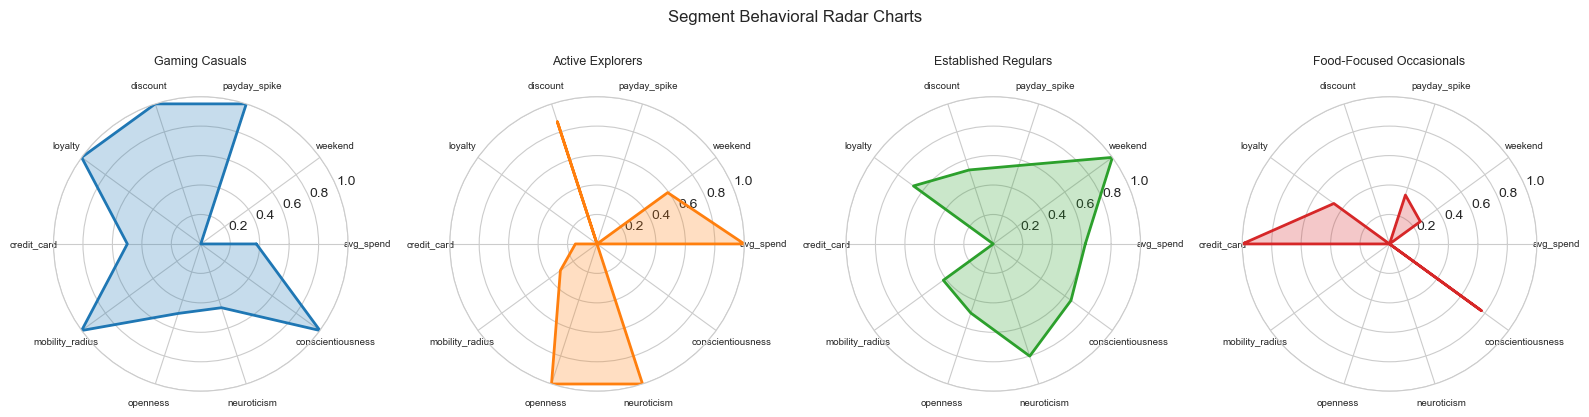

In [42]:
# Radar charts show each segment's behavioral profile across 10 key dimensions.
# Values are normalized to [0,1] relative to the min/max across all clusters,
# so the shape reflects relative standing, not absolute values.

radar_cols = ['avg_spend', 'weekend_ratio', 'payday_spike_ratio', 'discount_ratio',
              'loyalty_ratio', 'credit_card_ratio', 'mobility_radius', 'openness_score',
              'neuroticism_score', 'conscientiousness_score']
radar_cols = [c for c in radar_cols if c in users.columns]

radar_data = users.groupby('cluster')[radar_cols].mean()
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min() + 1e-9)

angles = np.linspace(0, 2 * np.pi, len(radar_cols), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(1, min(best_k, 5), figsize=(4 * min(best_k, 5), 4),
                          subplot_kw=dict(polar=True))
if best_k == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    if i >= best_k:
        ax.set_visible(False)
        continue
    values = radar_norm.iloc[i].tolist() + radar_norm.iloc[i].tolist()[:1]
    ax.plot(angles, values, color=palette[i], linewidth=2)
    ax.fill(angles, values, color=palette[i], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([c.replace('_ratio','').replace('_score','') for c in radar_cols], fontsize=7)
    ax.set_title(segment_names.get(i, f'Cluster {i}'), fontsize=9, pad=12)
    ax.set_ylim(0, 1)

plt.suptitle('Segment Behavioral Radar Charts', y=1.02)
plt.tight_layout()
plt.show()


In [43]:
# Demographic breakdown of inferred attributes per segment.
# Proportions are row-normalized — each row sums to 1.0.
# Use this to understand the typical inferred profile within each segment.

demo_cols = ['income_level','age_group','working_status','gender_proxy']
for col in demo_cols:
    print(f'\n--- {col} by segment ---')
    print(pd.crosstab(users['segment_name'], users[col], normalize='index').round(2))



--- income_level by segment ---
income_level               low  middle  high
segment_name                                
Active Explorers          0.05    0.63  0.33
Established Regulars      0.15    0.62  0.23
Food-Focused Occasionals  0.26    0.58  0.16
Gaming Casuals            0.16    0.61  0.22

--- age_group by segment ---
age_group                  50+  35-50  25-34  18-24
segment_name                                       
Active Explorers          0.01   0.42   0.56   0.01
Established Regulars      0.02   0.39   0.56   0.03
Food-Focused Occasionals  0.03   0.35   0.54   0.08
Gaming Casuals            0.00   0.16   0.69   0.15

--- working_status by segment ---
working_status            freelancer  home_based  office_worker  professional  \
segment_name                                                                    
Active Explorers                0.09        0.20           0.55          0.12   
Established Regulars            0.09        0.20           0.57          0.08

## Section 9 — Ethical Considerations

Demographic inference from transactional data carries inherent risks that must be acknowledged:

1. **Probabilistic, not factual.** All inferred attributes (gender, age, income, personality) are behavioral estimates, not verified facts. They reflect population-level correlations, not individual certainty.

2. **Cultural and socioeconomic bias.** Behavioral proxies are derived from patterns that may be culturally specific to Indonesia. Applying them in other contexts without recalibration could produce biased results.

3. **Self-reinforcing loops.** Using behavioral estimates to target users with certain products can reinforce the very patterns used to infer the estimate — creating feedback loops that limit user diversity.

4. **Fairness.** Inferred attributes must not be used for discriminatory decisions (e.g., denying credit, charging differential prices, limiting access to services).

5. **Privacy.** Geo-location derived home and work coordinates are sensitive. These should be stored with appropriate access controls and never shared at individual level.

## Section 10 — Conclusion

In [44]:
# Final segment summary table — one row per segment, key metrics averaged.
# This is the primary output for the business report.

summary = users.groupby('segment_name').agg(
    user_count          = ('user_id', 'count'),
    avg_spend           = ('avg_spend', 'mean'),
    avg_transactions    = ('transaction_count', 'mean'),
    avg_active_days     = ('active_days', 'mean'),
    credit_card_pct     = ('credit_card_ratio', 'mean'),
    discount_pct        = ('discount_ratio', 'mean'),
    loyalty_pct         = ('loyalty_ratio', 'mean'),
    merchant_diversity  = ('merchant_diversity', 'mean'),
    openness            = ('openness_score', 'mean'),
    conscientiousness   = ('conscientiousness_score', 'mean'),
    neuroticism         = ('neuroticism_score', 'mean'),
    mobility            = ('mobility_radius', 'mean'),
).round(3).reset_index()

summary['avg_spend'] = summary['avg_spend'].map('{:,.0f}'.format)
print(summary.to_string(index=False))


            segment_name  user_count avg_spend  avg_transactions  avg_active_days  credit_card_pct  discount_pct  loyalty_pct  merchant_diversity  openness  conscientiousness  neuroticism  mobility
        Active Explorers        5524    54,246            15.896           14.543            0.199         0.173        0.228              15.847     0.424              0.475        0.225     0.241
    Established Regulars       10302    50,996            11.580           10.843            0.197         0.171        0.246              11.553     0.334              0.484        0.222     0.242
Food-Focused Occasionals        6754    45,583             7.812            7.495            0.208         0.167        0.241               7.797     0.246              0.485        0.212     0.237
          Gaming Casuals        1741    48,849            10.949           10.268            0.203         0.174        0.254              10.916     0.334              0.488        0.218     0.249


## Segment Summaries & Business Recommendations

---

### Cluster 1 — Active Explorers (5,524 users, 23%)

**Who they are:** The platform's highest-value, most engaged users. They spend the most per transaction (avg IDR 54,246), transact the most frequently (15.9 tx), are active the most days per month (14.5), and visit the widest range of merchants (15.8 unique). Their openness score (0.424) is the highest of all segments, they seek variety and explore new merchants readily. Electronics is their distinguishing MCC category, pointing to tech-savvy spending behavior.

**Inferred demographics:** Skew toward high income (33%), predominantly 25–34 age group (56%), likely male (57%), office workers and professionals (67% combined).

**Personality profile:** High openness, moderate conscientiousness. Curious and active, but not necessarily disciplined — they transact frequently but don't necessarily stick to one merchant or category.

**Business opportunity:** Premium membership tiers, curated discovery features, cross-category recommendations. This segment has the highest lifetime value potential. Churn prevention is critical, even small retention improvements here have outsized revenue impact. Reward breadth of spending, not just volume.

---

### Cluster 2 — Established Regulars (10,302 users, 42%)

**Who they are:** The platform's largest and most stable segment. Moderate spend (IDR 50,996), moderate frequency (11.6 tx), moderate diversity (11.6 merchants). What distinguishes them is their MCC profile: highest pharmacy, fuel, and fashion ratios of all clusters, a spending pattern consistent with working adults managing health, commuting, and personal appearance. Conscientiousness score (0.484) is their highest personality trait.

**Inferred demographics:** Mix of 25–34 (56%) and 35–50 (39%), mix of income levels (62% middle), predominantly office workers (57%), slight female lean (34% female vs 46% male, lowest male skew of all segments).

**Personality profile:** Most conscientious segment. Routine-driven, organized, health-aware. Not impulsive, their spending is predictable and purposeful.

**Business opportunity:** Loyalty program deepening, insurance products, health-related financial products, cashback on pharmacy and fuel. This segment is the retention backbone, they won't churn easily, but they also won't upgrade without a clear value proposition. Focus on stickiness and cross-sell into adjacent financial products that match their established-adult lifestyle.

---

### Cluster 0 — Gaming Casuals (1,741 users, 7%)

**Who they are:** The smallest and most distinctive segment. Their only standout characteristic is gaming_ratio (0.102 — essentially zero in all other clusters). Everything else is average: spend (IDR 48,849), frequency (10.9 tx), active days (10.3). They are not outliers in any spending dimension except digital entertainment. The indeterminate gender proxy is highest here (0.0 — actually 0%, meaning all are coded as male or female with no ambiguity), and male skew is highest (94%).

**Inferred demographics:** Strongly male (94%), youngest skew within all segments (15% are 18–24 vs 1% in Active Explorers), lower income proportion (16% low vs 5% in Active Explorers).

**Personality profile:** Moderate neuroticism (erratic spending), lower agreeableness. Digital-native orientation but not broad-category explorers, their interest is narrow and specific.

**Business opportunity:** In-app gaming integrations, digital entertainment vouchers, gaming merchant partnerships. This is a niche segment with strong identity, they respond well to targeted offers that speak directly to their gaming lifestyle. Avoid generic campaigns. The 18–24 concentration makes them a long-term acquisition target as their spending power grows.

---

### Cluster 3 — Food-Focused Occasionals (6,754 users, 28%)

**Who they are:** The least active segment by every transactional measure, lowest spend (IDR 45,582), lowest frequency (7.8 tx), fewest active days (7.5). When they do transact, it is almost exclusively food: highest restaurant (0.257), fast food (0.141), and grocery ratios (0.151) of all clusters. Their merchant diversity is the lowest (7.8), reflecting a narrow, food-centric spending footprint. Openness score (0.246) is the lowest of all segments.

**Inferred demographics:** Youngest-leaning segment alongside Gaming Casuals, 69% in 25–34, 15% in 18–24. Low-to-middle income (77% combined). Office workers majority (57%) but with the highest student proportion (6%).

**Personality profile:** Low openness, moderate neuroticism. Routine and convenience-oriented. They use the platform as a food payment tool, not as a financial lifestyle hub.

**Business opportunity:** Food delivery partnerships, restaurant cashback, grocery rewards. The immediate goal is frequency activation — nudge these users beyond their food comfort zone with low-friction offers in adjacent categories (e.g. pharmacy cashback alongside grocery purchases). Long-term, converting even 20% of this segment to broader platform engagement would meaningfully shift their lifetime value.

---

### Behavioral Archetype Layer (Non-Traditional Segmentation)

The rule-based archetypes provide a complementary, fully interpretable segmentation that does not depend on distance metrics or random initialization.

| Archetype | Users | Defining Rule | Business Action |
|---|---|---|---|
| Loyal Power User | 2,808 (12%) | loyalty_ratio > 0.5 AND high frequency | VIP tier, early access, referral program |
| Deal Hunter | 1,239 (5%) | discount_ratio > 0.3 AND payday-concentrated | Salary-day flash sales, cashback campaigns |
| Stable Family Earner | 4,180 (17%) | high family_score AND weekend-heavy | Family bundles, insurance, education savings |
| Occasional User | 4,259 (18%) | active_days < bottom 25th percentile | Re-engagement push notifications, win-back offers |
| General User | 11,835 (49%) | everyone else | Broad platform awareness, habit-forming nudges |

---

### Known Limitations

- **Low silhouette scores (0.032–0.039):** Cluster boundaries are soft. Users near centroids are well-assigned; users at boundaries are ambiguous. Treat segment membership as probabilistic, not definitive.
- **3-month window:** Seasonal patterns, annual income cycles, and life-event spending (weddings, school enrollment) are invisible. A 12-month window would produce substantially richer temporal features.
- **No time-of-day data:** Work-hour and late-night behavioral signals, among the strongest lifestyle indicators, are entirely absent due to the dataset limitation.
- **MCC correlation with demographics is near-zero (max r=0.009):** Age, income, and education inferences are directional estimates only. They reflect population-level tendencies, not reliable individual labels.
- **City differences are minimal:** All three cities show nearly identical avg spend and credit card adoption rates. City-level models are unlikely to add significant value with this data.

### Future Improvements

1. Validate inferred demographics against opt-in survey data to calibrate proxy accuracy
2. Extend to 12-month transaction window for seasonal and lifecycle signals
3. Apply NLP to merchant names, raw names contain rich unlabeled category signals beyond MCC codes
4. Use UMAP for dimensionality reduction, better preserves local structure than PCA at low silhouette
5. Build ensemble segmentation: combine KMeans clusters with rule-based archetypes into a unified user profile score
